In [ ]:
pip install numpy opencv-python scikit-learn matplotlib

In [ ]:
pip install scikit-image

Loading images...

Loaded 4000 images

Training samples: 3200
Testing samples: 800

Training SVM...
Training Complete!

Accuracy: 76.62%

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.75      0.76       400
           1       0.76      0.78      0.77       400

    accuracy                           0.77       800
   macro avg       0.77      0.77      0.77       800
weighted avg       0.77      0.77      0.77       800


Generating prediction grid...

Prediction grid saved as:
prediction_grid.png


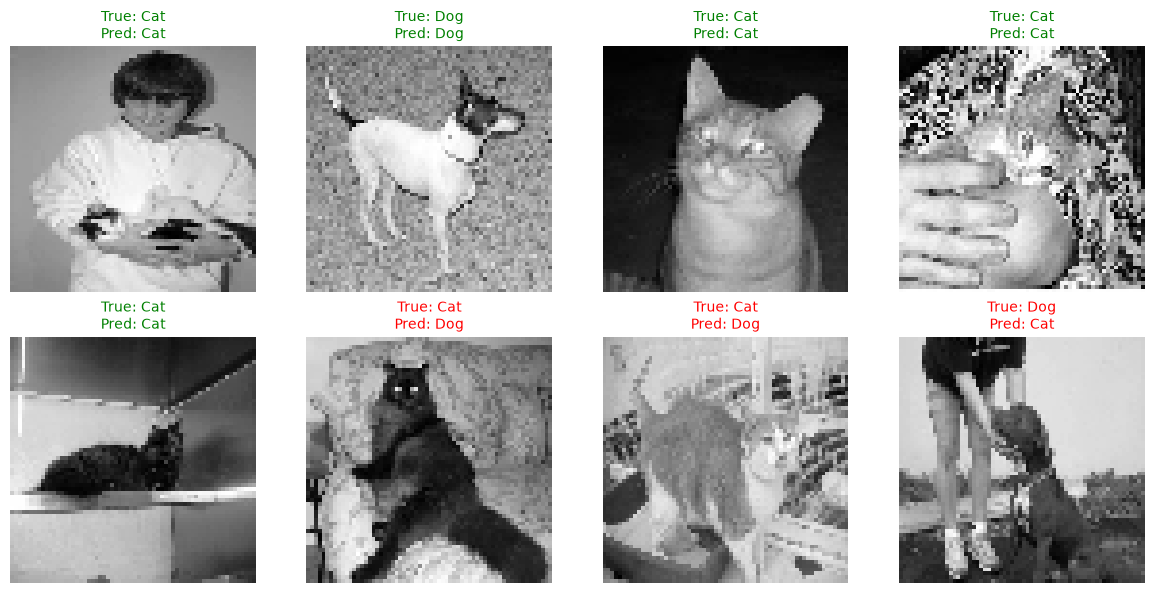

In [5]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# ==========================
# SETTINGS
# ==========================
DATASET_PATH = "train"   # Kaggle train folder
MAX_IMAGES = 4000        # 2000 cats + 2000 dogs
IMG_SIZE = (64, 64)

# ==========================
# LOAD DATA
# ==========================
features = []
labels = []
images = []

print("Loading images...")

cat_count = 0
dog_count = 0

for filename in os.listdir(DATASET_PATH):

    if filename.startswith("cat") and cat_count < 2000:
        label = 0
        cat_count += 1

    elif filename.startswith("dog") and dog_count < 2000:
        label = 1
        dog_count += 1

    else:
        continue

    filepath = os.path.join(DATASET_PATH, filename)

    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img = cv2.resize(img, IMG_SIZE)

    # Save original image for visualization
    images.append(img)

    # HOG feature extraction
    hog_features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    features.append(hog_features)
    labels.append(label)

    if len(features) >= MAX_IMAGES:
        break

print(f"\nLoaded {len(features)} images")

# ==========================
# CONVERT TO NUMPY
# ==========================
X = np.array(features)
y = np.array(labels)
images = np.array(images)

# ==========================
# TRAIN TEST SPLIT
# ==========================
X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X,
    y,
    images,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# ==========================
# TRAIN SVM
# ==========================
print("\nTraining SVM...")

model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

model.fit(X_train, y_train)

print("Training Complete!")

# ==========================
# PREDICTIONS
# ==========================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================
# VISUALIZE RESULTS
# ==========================
print("\nGenerating prediction grid...")

sample_indices = random.sample(
    range(len(X_test)),
    min(8, len(X_test))
)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(sample_indices):

    image = img_test[idx]

    true_label = "Cat" if y_test[idx] == 0 else "Dog"
    pred_label = "Cat" if y_pred[idx] == 0 else "Dog"

    color = "green" if y_test[idx] == y_pred[idx] else "red"

    plt.subplot(2, 4, i + 1)

    plt.imshow(image, cmap="gray")

    plt.title(
        f"True: {true_label}\nPred: {pred_label}",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()

# Save image
plt.savefig("prediction_grid.png")

print("\nPrediction grid saved as:")
print("prediction_grid.png")

# Show image
plt.show()